# 분석예제 1. 2019년 한일 수출규제와 한국의 대일 부가가치 의존

이 노트북은 연구문서 「2019년 한일 수출규제와 한국의 대일 부가가치 의존」의 IV장(산업 수준 증거)에 실린
모든 표와 그림을 처음부터 다시 만든다. 마지막 절이 본문에 인용된 수치를 하나씩 대조하므로,
노트북이 끝까지 오류 없이 돌면 본문의 숫자가 이 DB에서 실제로 나온다는 뜻이다.

**무엇이 필요한가.** DuckDB 파일 하나(`gvc.duckdb`)와 파이썬 패키지 다섯이다.
conda나 특정 파이썬 버전은 필요 없다.

```
pip install duckdb pandas numpy statsmodels matplotlib jupyter
```

교육용 축소판(`gvc_lite.duckdb`)으로도 그대로 돌아간다. 이 노트북은 계산해 둔 지표 계층(`mart_`)만 읽고
원표(`fact_icio_z`)를 읽지 않기 때문이다. 전체 실행에 1분이 채 걸리지 않는다.

**읽는 순서.** 각 절은 설명, 계산, 읽어낸 것의 순서로 놓았다. 표와 그림 모두 한글로 적는다.
그림의 한글 글꼴은 §0에서 잡는데, 윈도우가 아니어서 맞는 글꼴이 없으면 경고를 찍고 영문으로 물러선다.

## §0. 준비

DB 파일의 위치를 찾고 연결한다. 저장소 루트에서 주피터를 띄웠는지 이 노트북이 놓인 폴더에서 띄웠는지에
따라 상대경로가 달라지므로 몇 군데를 차례로 본다. 다른 프로세스가 이 파일을 잡고 있으면 열리지 않으니
그럴 때는 그 커널이나 스크립트를 먼저 끝낸다.

자료 버전과 지표 산식 판본을 여기서 한 번만 정한다. 확장판(`ICIO2025_EXT`)을 쓰는 이유는 중국을 가공무역과
비가공무역으로 쪼갠 표라야 OECD가 공표하는 부가가치 무역 통계를 재현하기 때문이다.
한국 전자 공급망에서 중국이 차지하는 몫을 생각하면 이쪽이 옳다. 표준판과의 차이는 §5에서 직접 확인한다.

In [1]:
import os, warnings
import duckdb, numpy as np, pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 60)

EDITION = 'ICIO2025_EXT'   # 확장판. 표준판은 'ICIO2025'
METHOD  = 'v1'             # 지표 산식 판본 (docs/method.md)

CANDIDATES = ['data/processed/gvc.duckdb', '../data/processed/gvc.duckdb',
              '../../data/processed/gvc.duckdb', '../../../data/processed/gvc.duckdb',
              'gvc.duckdb', '../gvc.duckdb', '../../gvc.duckdb',
              'data/processed/gvc_lite.duckdb', '../data/processed/gvc_lite.duckdb',
              '../../data/processed/gvc_lite.duckdb',
              'gvc_lite.duckdb', '../gvc_lite.duckdb', '../../gvc_lite.duckdb']
DB = next((p for p in CANDIDATES if os.path.exists(p)), None)
if DB is None:
    raise FileNotFoundError('gvc.duckdb 를 찾지 못했다. CANDIDATES 에 경로를 더하거나 파일을 옮긴다.')

con = duckdb.connect(DB, read_only=True)

# 그림에 쓸 한글 글꼴. 없으면 영문으로 물러선다.
from matplotlib import font_manager
HAVE = {f.name for f in font_manager.fontManager.ttflist}
KFONT = next((f for f in ['Malgun Gothic', 'NanumGothic', 'AppleGothic',
                          'Noto Sans CJK KR', 'Gulim'] if f in HAVE), None)
if KFONT is None:
    print('[경고] 한글 글꼴을 찾지 못했다. 그림 라벨이 깨질 수 있다.')
    KFONT = 'DejaVu Sans'
plt.rcParams.update({
    'font.family': KFONT,
    'axes.unicode_minus': False,      # 음수 기호를 U+2212 대신 ASCII 하이픈으로
    'font.size': 9.5,
    'axes.grid': True, 'grid.color': '0.87', 'grid.linewidth': 0.7,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 110, 'savefig.dpi': 500,
})

# 연구문서가 참조하는 경로에 그림을 파일로도 남긴다.
# 그 폴더가 이미 있을 때만 쓴다. 없으면 아무것도 만들지 않고 넘어간다.
FIGDIR = os.path.normpath(os.path.join(
    os.path.dirname(os.path.dirname(os.path.abspath(DB))), '..',
    'analysis', '1.일본수출규제와_공급망재편', 'fig'))
def savefig(fig, name):
    if not os.path.isdir(os.path.dirname(FIGDIR)):
        return
    try:
        os.makedirs(FIGDIR, exist_ok=True)
        fig.savefig(os.path.join(FIGDIR, name), bbox_inches='tight')
    except OSError:
        pass

print('DB      :', os.path.abspath(DB))
print('버전    :', EDITION, '/ 지표 산식 판본:', METHOD)
print('글꼴    :', KFONT)
print('연도범위:', con.sql(f"select min(year), max(year) from mart_gvc_core "
                          f"where edition='{EDITION}'").fetchone())

DB      : C:\Work\Projects\GVC\data\processed\gvc.duckdb
버전    : ICIO2025_EXT / 지표 산식 판본: v1
글꼴    : Malgun Gothic
연도범위: (1995, 2022)


## §1. 무엇을 어떻게 뽑는가

계산의 재료는 두 표다. `mart_gvc_core`는 국가·산업·연도마다 총수출과 국내·외국 부가가치 비중을 담고,
`mart_gvc_bilateral`은 거기에 상대국 축을 하나 더해 「그 수출에 실린 상대국 $r$의 부가가치」를 담는다.
이 문서에서 쓰는 대일 의존은 후자에서 $r = \text{JPN}$인 행이다. 방향에 주의한다.
`fva_from_partner`는 일본으로 **가는** 수출이 아니라 일본에서 **오는** 투입의 성질이다.

확장판에서는 개체와 경제권이 다르다. 중국이 `CN1`·`CN2` 두 개체로 쪼개져 있으므로
개체 이름만으로 국경을 세면 중국 내부 거래가 수출로 잡힌다. `dim_icio_entity.economy`로 접어서
경제권 단위로 합친 다음 비율을 다시 계산한다. 비중의 평균이 아니라 금액을 합치고 나누는 것이 요점이다.

아래 함수 하나가 국가×산업×연도 패널을 만든다. 한 번 만들어 두고 이후 절에서 계속 쓴다.

In [2]:
MFG = ['C10T12','C13T15','C16','C17_18','C19','C20','C21','C22','C23','C24A','C24B',
       'C25','C26','C27','C28','C29','C301','C302T309','C31T33']   # ICIO 제조업 19개

# 표에 찍을 국가명. 계산은 ISO 코드로 하고 보여줄 때만 바꾼다.
KNAME = {'CHN':'중국','KOR':'한국','TWN':'대만','USA':'미국','DEU':'독일','JPN':'일본',
         'VNM':'베트남','SGP':'싱가포르','MEX':'멕시코','MYS':'말레이시아','THA':'태국',
         'NLD':'네덜란드','CHE':'스위스','FRA':'프랑스','IRL':'아일랜드','PHL':'필리핀',
         'IND':'인도','ITA':'이탈리아','GBR':'영국','SAU':'사우디아라비아','ARE':'아랍에미리트',
         'RUS':'러시아','AUS':'오스트레일리아','IDN':'인도네시아','ROW':'잔차지역'}
def kr(x):
    # 열 이름이나 색인을 한글로. 사전에 없으면 코드를 그대로 둔다.
    return [KNAME.get(c, c) for c in x]

def load_panel(edition=EDITION, y0=1995, y1=2022):
    # 국가(경제권) x 산업 x 연도: 총수출과 그 수출에 실린 일본 부가가치
    q = f'''
    select c.year, e.economy as cty, c.ind,
           sum(c.exgr) as exgr,
           sum(coalesce(b.fva_from_partner, 0)) as fva_jpn
    from mart_gvc_core c
    join dim_icio_entity e
      on e.edition = c.edition and e.code = c.cty
    left join mart_gvc_bilateral b
      on  b.edition = c.edition and b.method_version = c.method_version
      and b.year = c.year and b.cty = c.cty and b.ind = c.ind
      and b.partner = 'JPN'
    where c.edition = '{edition}' and c.method_version = '{METHOD}'
      and c.year between {y0} and {y1}
    group by 1, 2, 3'''
    d = con.sql(q).df()
    d['jsh'] = d.fva_jpn / d.exgr        # 총수출 중 일본 부가가치 비중
    return d

panel = load_panel()
print('패널:', panel.cty.nunique(), '경제권 x', panel.ind.nunique(), '산업 x',
      panel.year.nunique(), '연도 =', len(panel), '행')
panel.head()

패널: 81 경제권 x 50 산업 x 28 연도 = 113400 행


,year,cty,ind,exgr,fva_jpn,jsh
0,1995,HKG,C301,53.0347,2.258222,0.042580
1,1995,HKG,F,91.1712,2.086387,0.022884
2,1995,HKG,H49,1142.2001,16.115340,0.014109
3,1995,HKG,H51,4348.7336,259.570631,0.059689
4,1995,HKG,J58T60,412.6822,17.781000,0.043086


## §2. 총액 기준과 부가가치 기준은 갈라지는가 (본문 그림 1)

정부와 언론이 쓰는 대일 의존도는 총액 기준이다. 세번별 수입액을 분자와 분모로 삼으므로,
조달처를 일본에서 벨기에로 바꾸었더라도 그 벨기에 물량이 일본산 중간재로 만들어졌다면
실질 의존은 줄지 않았는데 지표는 줄어든 것으로 보인다. 부가가치 기준은 이 문제를 원리적으로 피한다.
한국 수출에 실린 일본 부가가치는 경로가 몇 나라를 거치든 발생지인 일본에 귀속되기 때문이다.

두 척도를 나란히 낸다. 첫 열은 한국이 세계에서 사들인 총액 중 일본에서 온 몫이고,
둘째 열은 **같은 수입액**을 그 안에 담긴 부가가치의 발생지별로 갈라 일본 몫을 잰 것이다.
분모도 가중치도 같고 거래액을 그대로 세는지 그 안의 부가가치로 세는지에서만 다르므로
곧바로 견줄 수 있다. 수준이 아니라 2018년 대비 변화를 읽는다.

§3 이후에서 쓰는 계열은 이것이 아니라 수출 부가가치 기준이다. 산업 수준에서 노출을 재려면
그 산업이 일본에서 직접 사들인 것만으로는 모자라기 때문이다. 국내 다른 산업을 거쳐 온 몫과
제3국을 거쳐 온 몫이 빠진다. 그 크기를 §3 첫머리에서 확인한다.

그림 1의 바탕값. 한국 수입의 대일 의존, 총액 기준과 부가가치 기준 (%)


,수입 총액 기준,수입 부가가치 기준
year,,
2014,8.95,8.23
2015,8.73,8.47
2016,9.91,9.84
2017,9.99,9.73
2018,9.02,8.64
2019,8.16,7.97
2020,8.39,8.28
2021,7.58,7.36
2022,7.08,6.38



2018 -> 2022 감소율 (%)
수입 총액 기준      21.5
수입 부가가치 기준    26.2

수입 분해가 닫히는지: Σ 상대국 부가가치 대 총수입, 상대오차 최댓값 2.0e-15


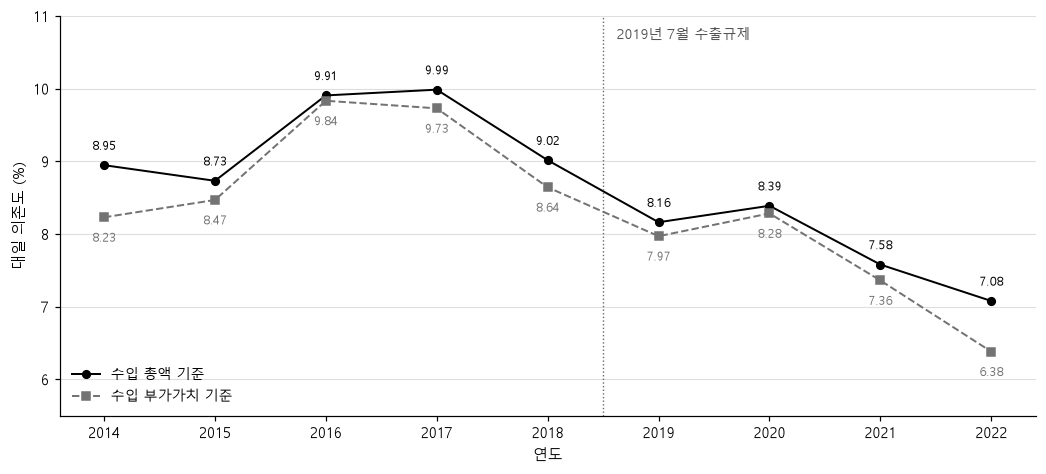

In [3]:
q = f'''
with m as (
  select year,
         sum(imp_from_partner) filter (partner = 'JPN')  as ig,
         sum(imp_from_partner)                            as it,
         sum(va_from_partner)  filter (partner = 'JPN')  as vg,
         sum(va_from_partner)  filter (partner <> 'KOR') as vf,
         sum(va_from_partner)                             as vall
  from mart_gvc_import_va
  where edition = '{EDITION}' and method_version = '{METHOD}' and cty = 'KOR'
  group by 1)
select m.year, m.ig / m.it * 100 as a, m.vg / m.vf * 100 as b,
       abs(m.vall - m.it) / m.it as closure
from m order by 1'''

T1 = con.sql(q).df().set_index('year')
CLOSURE = T1.pop('closure').max()   # Σ_p 부가가치 = 총수입 인지
T1.columns = ['수입 총액 기준', '수입 부가가치 기준']
print('그림 1의 바탕값. 한국 수입의 대일 의존, 총액 기준과 부가가치 기준 (%)')
display(T1.loc[2014:2022].round(2))
print('\n2018 -> 2022 감소율 (%)')
print(((1 - T1.loc[2022] / T1.loc[2018]) * 100).round(1).to_string())
print(f'\n수입 분해가 닫히는지: Σ 상대국 부가가치 대 총수입, 상대오차 최댓값 {CLOSURE:.1e}')

YY = T1.loc[2014:2022]
fig, ax = plt.subplots(figsize=(9.6, 4.4))
ax.xaxis.grid(False)
for col, mk, ls, c, dy in [('수입 총액 기준', 'o', '-', 'black', 10),
                           ('수입 부가가치 기준', 's', '--', '0.45', -16)]:
    ax.plot(YY.index, YY[col], marker=mk, ls=ls, color=c, lw=1.3, ms=5, label=col)
    for xx, vv in YY[col].items():
        ax.annotate(f'{vv:.2f}', (xx, vv), textcoords='offset points',
                    xytext=(0, dy), ha='center', fontsize=8.5, color=c)
ax.set_xticks(list(YY.index))
ax.set_ylim(5.5, 11.0)
ax.axvline(2018.5, color='0.4', lw=0.9, ls=':')
ax.text(2018.62, 10.85, '2019년 7월 수출규제', fontsize=9, color='0.3', va='top')
ax.set_xlabel('연도')
ax.set_ylabel('대일 의존도 (%)')
ax.legend(frameon=False, fontsize=9, loc='lower left')
fig.tight_layout()
savefig(fig, 'fig1_dep.png')
plt.show()

2018년에서 2022년 사이 수입 총액 기준이 21.5%, 수입 부가가치 기준이 26.2% 낮아졌다.
부가가치 쪽이 더 크게 줄었다는 것이 핵심이다. 한국이 일본산 소재를 제3국을 통해 계속 사들이고
있었다면 총액에서는 줄어도 부가가치에서는 줄지 않아야 하는데 관측된 것은 그 반대다.
집계 수준에서 「경유지 변경의 착시」라는 해석은 지지되지 않는다.

다만 표는 이 감소가 2019년에 시작된 것이 아님을 함께 보여 준다. 2016년과 2017년이 국소적 고점이고
2018년에 이미 하락이 시작되어 있다. 이 관측이 §5와 §6의 출발점이다.

## §3. 어느 산업에서 줄었는가 (본문 표 1)

산업별로 나누면 감소가 규제가 겨눈 곳에서 일어났는지를 물을 수 있다. 2018년 수출액 상위 10개 산업을
골라 각 산업 수출에 실린 일본 부가가치의 비중을 시계열로 놓는다. 규제의 실수요 산업은
컴퓨터·전자·광학기기(C26)이고, 규제 3품목이 분류상 속하는 곳은 화학(C20)이다.

In [4]:
# 산업 수준 노출을 왜 상류를 훑는 척도로 재는가 — 국내 조달 경로가 빠진다
q = f'''select b.fva_from_partner_share sh, c.out X
from mart_gvc_bilateral b
join mart_gvc_core c on c.edition = b.edition and c.method_version = b.method_version
  and c.year = b.year and c.cty = b.cty and c.ind = b.ind
where b.edition = '{EDITION}' and b.method_version = '{METHOD}'
  and b.cty = 'KOR' and b.ind = 'C26' and b.partner = 'JPN' and b.year = 2018'''
SH, XOUT = con.sql(q).fetchone()
TOT = SH * XOUT                     # 산출 전체에 담긴 일본 부가가치
HAS_Z = con.sql("select count(*) from duckdb_tables() "
                "where table_name='fact_icio_z'").fetchone()[0] > 0
DOM = THIRD = DIR = None
if HAS_Z:
    # C26 이 사들인 중간재를 공급처별로 놓고, 각 공급처 산출의 일본 부가가치 함량을 곱한다.
    # 일본 공급분의 함량은 mart 에 없으므로(자기 경제권은 0 으로 저장) 잔차로 얻는다.
    q = f'''with z as (
  select src_cty, src_ind, sum(value) v from fact_icio_z
  where edition = '{EDITION}' and year = 2018
    and dst_cty = 'KOR' and dst_ind = 'C26'
  group by 1, 2)
select z.src_cty, sum(z.v * coalesce(b.fva_from_partner_share, 0)) jva
from z left join mart_gvc_bilateral b
  on b.edition = '{EDITION}' and b.method_version = '{METHOD}' and b.year = 2018
 and b.partner = 'JPN' and b.cty = z.src_cty and b.ind = z.src_ind
group by 1'''
    ch = con.sql(q).df().set_index('src_cty').jva
    DOM = float(ch.get('KOR', 0.0))
    THIRD = float(ch.drop(index=['KOR', 'JPN'], errors='ignore').sum())
    DIR = TOT - DOM - THIRD         # 항등식: 세 경로의 합이 총량이다

print(f'2018 한국 C26 산출에 담긴 일본 부가가치   {TOT/100:>8,.1f}억 달러')
if HAS_Z:
    for nm, v in [('일본에서 직접 들여온 중간재', DIR), ('제3국을 거쳐 들여온 중간재', THIRD),
                  ('국내 다른 산업에서 사들인 것', DOM)]:
        print(f'  {nm:<16} {v/100:>8,.1f}억 달러  ({v/TOT*100:4.1f}%)')
else:
    print('  원표(fact_icio_z)가 없는 축소판이라 경로 분해는 계산하지 않는다.')

kor = panel[panel.cty == 'KOR']
top10 = kor[kor.year == 2018].nlargest(10, 'exgr')['ind'].tolist()

T2 = kor[kor.ind.isin(top10)].pivot(index='year', columns='ind', values='jsh')[top10] * 100
print('표 1. 한국의 산업별 수출에 실린 일본 부가가치 비중 (%)')
display(T2.loc[2014:2022].round(2))

names = con.sql(f"select icio_ind, name_en from dim_icio_ind where edition='{EDITION}'").df()
names = names.set_index('icio_ind')['name_en']
print('\n2018년 수출액(백만 달러)과 산업명')
display(pd.DataFrame({'2018 수출': kor[kor.year == 2018].set_index('ind').loc[top10, 'exgr'].round(0),
                      '산업명': names.loc[top10]}))

2018 한국 C26 산출에 담긴 일본 부가가치      100.8억 달러
  일본에서 직접 들여온 중간재      50.4억 달러  (50.0%)
  제3국을 거쳐 들여온 중간재      12.6억 달러  (12.6%)
  국내 다른 산업에서 사들인 것     37.8억 달러  (37.5%)
표 1. 한국의 산업별 수출에 실린 일본 부가가치 비중 (%)


ind,C26,C20,C29,G,C19,C28,C27,C24A,C301,H50
year,,,,,,,,,,
2014,3.58,3.44,4.08,1.06,0.62,4.42,4.21,3.83,5.13,1.94
2015,3.02,2.97,3.61,0.91,0.76,3.79,3.52,3.12,4.30,2.16
2016,3.21,3.35,3.80,1.02,0.78,4.21,3.97,3.15,4.59,3.19
2017,3.15,3.31,3.97,1.03,0.81,4.46,4.03,3.19,4.40,2.64
2018,2.80,2.93,3.65,1.04,0.72,4.02,3.60,2.98,4.58,2.61
2019,2.70,3.04,3.45,0.81,0.74,3.58,3.35,3.00,4.11,2.87
2020,2.56,2.74,3.30,1.02,1.06,3.40,3.30,3.01,4.03,2.06
2021,2.26,3.00,3.24,0.89,0.63,3.56,3.21,2.88,4.17,1.51
2022,2.50,2.42,3.03,0.86,0.48,3.74,3.42,2.93,5.40,1.47



2018년 수출액(백만 달러)과 산업명


,2018 수출,산업명
C26,190031.0,"Manufacture of computer, electronic and optica..."
C20,65031.0,Manufacture of chemicals and chemical products
C29,59815.0,"Manufacture of motor vehicles, trailers and se..."
G,57411.0,Wholesale and retail trade; repair of motor ve...
C19,47121.0,Manufacture of coke and refined petroleum prod...
C28,46452.0,Manufacture of machinery and equipment n.e.c.
C27,30252.0,Manufacture of electrical equipment
C24A,25089.0,Manufacture of basic iron and steel
C301,19240.0,Building of ships and boats
H50,16466.0,Water transport


C26은 2018년 2.80%에서 2021년 2.26%까지 낮아졌다가 2022년 2.50%로 되올랐다.
C20은 2019년에 오히려 2.93%에서 3.04%로 올랐다. 어느 쪽에서도 2019년을 기점으로 한 단절은 보이지 않는다.

C20을 읽을 때는 따로 주의한다. 한국 화학산업의 외국 부가가치는 대부분 원유이므로 이 계열은
유가 변동을 크게 반영하며 대일 의존의 지표로 삼기에 적합하지 않다. 아래에서 상대국 구성을 직접 보면
사우디아라비아·아랍에미리트·러시아·오스트레일리아가 일본보다 큰 몫을 차지하는 것이 드러난다.

In [5]:
q = f'''select year, partner, sum(fva_from_partner) as v from mart_gvc_bilateral
where edition='{EDITION}' and method_version='{METHOD}' and cty='KOR' and ind='C20'
group by 1,2'''
c20 = con.sql(q).df()
c20['sh'] = c20.v / c20.year.map(c20.groupby('year')['v'].sum()) * 100
p20 = c20.pivot(index='year', columns='partner', values='sh')
ref20 = p20.loc[2016:2022, p20.loc[2018].nlargest(8).index].round(2)
ref20.columns = kr(ref20.columns)
print('참고. 한국 C20 외국 부가가치의 상대별 구성 (%) — 원유 수출국이 상위를 차지한다')
display(ref20)

참고. 한국 C20 외국 부가가치의 상대별 구성 (%) — 원유 수출국이 상위를 차지한다


,잔차지역,미국,사우디아라비아,중국,아랍에미리트,일본,러시아,오스트레일리아
year,,,,,,,,
2016,20.91,9.17,9.51,9.80,9.14,9.24,3.12,2.75
2017,21.07,9.50,9.21,9.95,9.52,8.51,3.82,2.94
2018,21.07,10.81,10.78,9.83,7.15,7.04,5.05,3.44
2019,19.88,13.25,9.52,10.43,8.24,7.11,4.49,3.30
2020,16.27,13.95,8.43,10.85,7.49,6.67,6.12,3.62
2021,12.75,12.93,7.58,17.34,3.49,7.69,3.93,4.62
2022,14.55,13.24,10.31,15.86,4.18,5.27,2.45,6.04


## §4. 국제 비교와 종점 민감도 (본문 표 2·표 3)

한국의 감소가 규제에 대한 반응인지, 아니면 일본이 세계 공급자로서 후퇴하는 공통 추세인지는
다른 나라와 견주어야 갈린다. C26에 한정해 2018년 수출액 상위 경제들의 같은 지표를 놓는다.
일본 자신은 이 값이 외국 부가가치가 아니라 자국 부가가치가 되므로 비교에서 뺀다.

In [6]:
c26 = panel[panel.ind == 'C26']
big = [c for c in c26[c26.year == 2018].nlargest(12, 'exgr')['cty'].tolist() if c != 'JPN']

T3 = c26[c26.cty.isin(big)].pivot(index='year', columns='cty', values='jsh')[big] * 100
sh  = c26.pivot(index='year', columns='cty', values='jsh')
# 변화율은 비율의 비로 곧장 낸다. 로그를 거치지 않으므로 환산이 필요 없다.
chg = ((sh.loc[2022] / sh.loc[2018] - 1) * 100).replace([np.inf, -np.inf], np.nan).dropna()

print('표 2. 주요 수출국의 C26 수출에 실린 일본 부가가치 비중 (%)')
out = T3.loc[2014:2022].round(2)
out.loc['변화율 2018~2022 (%)'] = chg.loc[big].round(1)
out.columns = kr(out.columns)
display(out)

print('\n변화율  한국 %+.1f%% / 80개 경제 중위 %+.1f%%' % (chg['KOR'], chg.median()))
print('한국보다 더 크게 줄인 경제 %.0f%%' % ((chg < chg['KOR']).mean() * 100))

표 2. 주요 수출국의 C26 수출에 실린 일본 부가가치 비중 (%)


,중국,한국,대만,미국,독일,베트남,싱가포르,멕시코,말레이시아,태국,네덜란드
year,,,,,,,,,,,
2014,3.64,3.58,7.33,0.28,1.24,4.39,12.17,3.71,5.85,9.18,5.70
2015,3.15,3.02,6.26,0.26,1.25,4.05,8.86,3.05,5.01,7.45,8.61
2016,3.56,3.21,6.63,0.31,1.43,4.26,9.09,3.21,5.21,7.95,8.54
2017,3.24,3.15,5.92,0.34,1.39,4.43,6.71,3.15,5.09,8.19,8.28
2018,3.01,2.80,5.66,0.29,1.29,4.55,4.59,3.23,4.75,7.69,7.93
2019,3.37,2.70,5.33,0.27,1.20,4.66,4.60,2.88,4.63,6.99,4.47
2020,3.13,2.56,4.59,0.23,1.14,4.51,4.40,2.75,4.83,6.16,3.45
2021,2.85,2.26,3.83,0.23,1.04,3.79,3.84,2.51,4.21,5.91,2.14
2022,2.45,2.50,3.47,0.35,1.05,3.73,3.23,2.13,3.50,5.85,2.10



변화율  한국 -10.5% / 80개 경제 중위 -20.1%
한국보다 더 크게 줄인 경제 72%


미국만 늘었고 나머지는 모두 줄었다. 줄어든 쪽에서는 한국의 감소폭이 가장 작다.
그런데 이 비교는 끝점에 민감하다. 시작을 2018년에 고정한 채 종점만 옮겨 같은 계산을 되풀이하면
한국의 자리가 중위를 넘나든다. 마지막에서 둘째 열은 한국보다 더 크게 줄인 경제가 전체에서
차지하는 비중이다. 대만을 따로 싣는 것은 C26 에서 한국 다음가는 수출국이면서 규제를 받지 않아
비교 대상으로 가장 가깝기 때문이다.

In [7]:
rows = []
for end in [2020, 2021, 2022]:
    ch = ((sh.loc[end] / sh.loc[2018] - 1) * 100).replace([np.inf, -np.inf], np.nan).dropna()
    rows.append([f'{end}년까지', ch['KOR'], ch['TWN'], ch.median(),
                 int((ch < ch['KOR']).sum()), len(ch)])
T3b = pd.DataFrame(rows, columns=['기준 2018년', '한국', '대만', '80개 경제 중위',
                                  '한국보다 큰 폭 감소(개)', 'N']).set_index('기준 2018년')
print('표 3. C26 대일 의존 변화율의 종점 민감도 (%)')
display(T3b.round(1))

표 3. C26 대일 의존 변화율의 종점 민감도 (%)


,한국,대만,80개 경제 중위,한국보다 큰 폭 감소(개),N
기준 2018년,,,,,
2020년까지,-8.7,-18.9,-11.7,43,80
2021년까지,-19.4,-32.2,-18.3,37,80
2022년까지,-10.5,-38.7,-20.1,58,80


2021년까지로 끊으면 한국은 중위보다 조금 더 줄인 쪽이고, 2022년까지 늘리면 덜 줄인 쪽으로 넘어간다.
원인은 2022년 한 해다. 표 2에서 한국만 2.26%에서 2.50%로 되올랐는데, 그 해 메모리 반도체 가격이
크게 내려 분모인 한국 C26 수출액이 눌린 것과 분리되지 않는다. 그래서 세 종점 모두에서 견디는
진술만 남긴다. 한국의 감소폭은 중위 부근이며 어느 종점에서도 분포의 극단이 아니다.
대만과의 비교는 종점과 무관하게 성립해, 대만이 언제나 한국의 1.7배에서 3.7배로 줄였다.

2022년 종점에서 80개 경제의 변화율은 -73.5% 에서 +78.0% 에 걸쳐 있고 그중 69개가 줄었다.
한국 주위는 간격이 촘촘해 뚜렷한 단절이 없다.

## §5. 이중차분 — 추정 창과 버전에 대한 민감도 (본문 표 4)

§4의 비교를 회귀로 옮긴다. 결과변수는 $y_{cit} = \ln(\text{일본 부가가치} / \text{총수출})$이고
추정식은 다음과 같다.

$$
y_{cit} = \beta \cdot \mathbf{1}[c=\text{KOR}] \cdot \mathbf{1}[t \ge 2019] + \alpha_{ci} + \gamma_{it} + \varepsilon_{cit}
$$

$\alpha_{ci}$는 국가×산업 고정효과, $\gamma_{it}$는 산업×연도 고정효과다. 뒤의 항이 산업별 세계 공통
충격을 흡수하므로 $\beta$는 동일 산업 안에서 한국이 다른 나라들의 공통 추세로부터 벗어난 정도를 잰다.
표본은 제조업 19개, 일본과 잔차지역을 뺀 경제들이며, 수출 1억 달러 미만이거나 일본 부가가치가 0인 칸은
제외한다. 표준오차는 국가로 군집화한다.

추정 창의 시작연도를 셋으로, 자료 버전을 둘로 바꾸어 여섯 번 추정한다. 하나의 명세만 보고했을 때
어떤 일이 벌어지는지를 보이는 것이 이 절의 목적이다.

In [8]:
def make_reg_panel(edition, y0, only=None):
    p = load_panel(edition, y0, 2022)
    p = p[(p.exgr > 100) & (p.fva_jpn > 0) & (p.ind.isin(MFG)) &
          (~p.cty.isin(['JPN', 'ROW']))].copy()
    p['y']  = np.log(p.jsh)
    p['ci'] = p.cty + '_' + p.ind                 # 국가 x 산업
    p['it'] = p.ind + '_' + p.year.astype(str)    # 산업 x 연도
    n = p.groupby('ci')['year'].nunique()         # 균형패널만 남긴다
    p = p[p.ci.isin(n[n == 2023 - y0].index)].copy()
    if only:
        p = p[p.ind == only].copy()
    return p

def did(edition, y0, only=None):
    p = make_reg_panel(edition, y0, only)
    p['did'] = ((p.cty == 'KOR') & (p.year >= 2019)).astype(int)
    f = 'y ~ did + C(cty) + C(year)' if only else 'y ~ did + C(ci) + C(it)'
    m = smf.ols(f, data=p).fit(cov_type='cluster', cov_kwds={'groups': p['cty']})
    return m.params['did'], m.bse['did'], int(m.nobs)

rows = []
for ed, lab in [(EDITION, '확장판'), ('ICIO2025', '표준판')]:
    for y0 in [2012, 2015, 2016]:
        a = did(ed, y0)
        b = did(ed, y0, 'C26')
        rows.append([lab, y0, a[0], a[1], a[2], b[0], b[1], b[2]])

T4 = pd.DataFrame(rows, columns=['버전', '시작연도', '제조업 beta', 's.e.', 'N',
                                 'C26 beta', 's.e. ', 'N '])
print('표 4. 이중차분 추정치 — 추정 창과 버전에 대한 민감도')
display(T4.round(4))   # 셋째 자리 반올림에서 판별이 흐려지는 값이 있어 넷째 자리까지 적는다

표 4. 이중차분 추정치 — 추정 창과 버전에 대한 민감도


,버전,시작연도,제조업 beta,s.e.,N,C26 beta,s.e.,N
0,확장판,2012,-0.1816,0.0247,11913,-0.1520,0.0366,627
1,확장판,2015,-0.0845,0.0206,8768,-0.0007,0.0321,456
2,확장판,2016,-0.0837,0.0200,7693,0.0157,0.0301,399
3,표준판,2012,-0.1823,0.0247,11913,-0.1519,0.0365,627
4,표준판,2015,-0.0846,0.0207,8768,0.0003,0.0321,456
5,표준판,2016,-0.0839,0.0201,7693,0.0167,0.0301,399


계수를 소수 넷째 자리까지 적은 것은 셋째 자리 반올림에서 판별이 흐려지는 값이 있기 때문이다.
결과변수가 로그이므로 아래 서술은 계수를 $\exp(\beta)-1$로 환산한 비율변화로 적는다. 표는 계수 그대로다.

표에서 세 가지가 드러난다. 버전의 선택은 결과를 바꾸지 않는다. 여섯 쌍 가운데 확장판과 표준판의
차이가 가장 큰 곳도 $0.1$%p 미만이다. 반면 추정 창의 시작연도는 결과를 크게 바꾼다. 2012년 시작이면
제조업 전체에서 $-16.6\%$이지만 2015년 시작이면 절반 이하인 $-8.1\%$가 된다. C26만 떼면 더 극적이다.
2012년 시작에서 유의하던 $-14.1\%$가 2015년 시작에서 $-0.1\%$로 사라지고 2016년 시작에서는 부호가 바뀐다.
하나의 명세를 골라 보고했다면 정반대의 결론을 내렸을 것이다.

## §6. 이벤트 스터디 — 민감도의 원인 (본문 표 5, 그림 2)

민감도의 원인은 사전 추세다. 기준연도를 2018년으로 두고 한국과 각 연도의 상호작용을 따로 추정하면
계수가 언제 어떤 형태로 움직였는지가 드러난다. 두 가지 추정 창에서 각각 구한다.

In [9]:
def event_study(y0, edition=EDITION):
    p = make_reg_panel(edition, y0)
    ks = [k for k in range(y0, 2023) if k != 2018]
    for k in ks:
        p[f'e{k}'] = ((p.cty == 'KOR') & (p.year == k)).astype(int)
    m = smf.ols('y ~ ' + ' + '.join(f'e{k}' for k in ks) + ' + C(ci) + C(it)',
                data=p).fit(cov_type='cluster', cov_kwds={'groups': p['cty']})
    r = pd.DataFrame({'계수': [m.params[f'e{k}'] if k != 2018 else 0.0 for k in range(y0, 2023)],
                      's.e.': [m.bse[f'e{k}']    if k != 2018 else 0.0 for k in range(y0, 2023)]},
                     index=range(y0, 2023))
    r['95% 하한'] = r['계수'] - 1.96 * r['s.e.']
    r['95% 상한'] = r['계수'] + 1.96 * r['s.e.']
    return r

EV12 = event_study(2012)
EV15 = event_study(2015)
yrs = list(range(2012, 2023))
T5 = pd.DataFrame(index=yrs)
for lab, r in [('2012년 시작 창', EV12), ('2015년 시작 창', EV15)]:
    rr = r.reindex(yrs)
    co_, ci_ = [], []
    for y in yrs:
        v = rr.loc[y, '계수']
        if pd.isna(v):
            co_.append('—'); ci_.append('—')
        elif y == 2018:
            co_.append('0 (기준)'); ci_.append('—')
        else:
            co_.append(f'{v:+.4f}')
            ci_.append(f"[{rr.loc[y, '95% 하한']:+.3f}, {rr.loc[y, '95% 상한']:+.3f}]")
    T5[lab + ' 계수'] = co_
    T5[lab + ' 95% 신뢰구간'] = ci_
print('표 5. 한국 제조업의 대일 부가가치 의존 — 타국 대비 연도별 이탈 (기준 2018년)')
display(T5)

표 5. 한국 제조업의 대일 부가가치 의존 — 타국 대비 연도별 이탈 (기준 2018년)


,2012년 시작 창 계수,2012년 시작 창 95% 신뢰구간,2015년 시작 창 계수,2015년 시작 창 95% 신뢰구간
2012,+0.3186,"[+0.262, +0.375]",—,—
2013,+0.3094,"[+0.251, +0.367]",—,—
2014,+0.1511,"[+0.098, +0.205]",—,—
2015,+0.0309,"[-0.013, +0.074]",+0.0302,"[-0.014, +0.074]"
2016,+0.0320,"[-0.004, +0.068]",+0.0334,"[-0.003, +0.070]"
2017,+0.0567,"[+0.023, +0.090]",+0.0573,"[+0.024, +0.091]"
2018,0 (기준),—,0 (기준),—
2019,-0.0579,"[-0.091, -0.025]",-0.0588,"[-0.092, -0.026]"
2020,-0.0341,"[-0.081, +0.013]",-0.0352,"[-0.082, +0.012]"
2021,-0.0760,"[-0.126, -0.026]",-0.0772,"[-0.127, -0.027]"


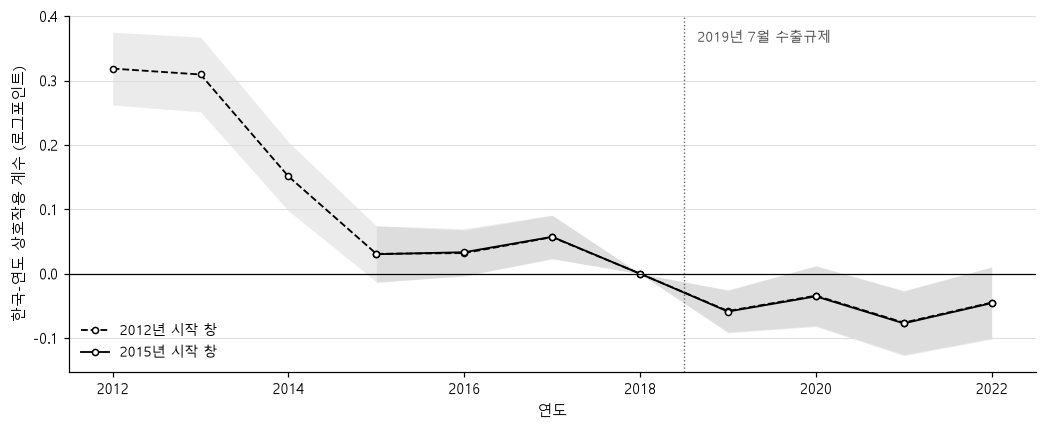

In [10]:
fig, ax = plt.subplots(figsize=(9.6, 4.0))
ax.xaxis.grid(False)
for r, ls, lab in [(EV12, '--', '2012년 시작 창'), (EV15, '-', '2015년 시작 창')]:
    ax.plot(r.index, r['계수'], ls, color='black', lw=1.2, marker='o', mfc='white', ms=4, label=lab)
    ax.fill_between(r.index, r['95% 하한'], r['95% 상한'], color='0.75', alpha=0.30, lw=0)
ax.axhline(0, color='black', lw=0.8)
ax.axvline(2018.5, color='0.4', lw=0.9, ls=':')
ax.text(2018.65, ax.get_ylim()[1] * 0.90, '2019년 7월 수출규제', fontsize=9, color='0.3')
ax.set_xlabel('연도')
ax.set_ylabel('한국-연도 상호작용 계수 (로그포인트)')
ax.legend(frameon=False, fontsize=9, loc='lower left')
fig.tight_layout()
savefig(fig, 'fig2_event.png')
plt.show()

여기서도 서술은 비율변화로 적는다. 2012년과 2013년의 추정치가 $+37.5\%$와 $+36.3\%$이고 2014년이
$+16.3\%$다. 한국의 대일 부가가치 의존은 2012년부터 2015년까지 세계 평균보다 훨씬 빠르게 낮아지고
있었다. 이 구간을 사전 기간에 넣으면 사전 평균이 높아져 사후와의 차이가 자동으로 커진다.
표 4의 $-16.6\%$는 대부분 이 사전 추세다.

2015년에서 시작하면 사전 추정치가 $+3.1\%$, $+3.4\%$, $+5.9\%$로 훨씬 평평해지지만 완전하지는 않다.
2017년 계수의 신뢰구간이 0을 포함하지 않으므로 평행추세 가정은 이 창에서도 엄밀하게는 기각된다.
사후 추정치는 2019년 $-5.7\%$, 2020년 $-3.5\%$, 2021년 $-7.4\%$, 2022년 $-4.5\%$다.
2019년에 음의 값으로 내려가 그 수준에 머무는 형태이지만, 2018년 기준값 자체가 2017년 고점에서
내려온 자리라 이 하락의 일부는 복귀다. 정리하면 2019년 이후 한국의 대일 의존은 세계 추세 대비
3%에서 7% 사이로 낮아졌고, 사전 추세가 남아 있으므로 이것은 효과의 상한이다.

## §7. 무엇이 일본을 대신했는가 (본문 표 6)

일본의 몫이 줄었다면 그 자리를 무엇이 채웠는지가 다음 질문이다. 한국 C26 수출에 실린 외국 부가가치를
발생 경제별로 나누어 구성비로 놓는다. 분모가 외국 부가가치 총액이므로 행의 합이 100이며,
어느 상대의 비중이 오르면 다른 상대의 비중은 정의상 내린다.

In [11]:
q = f'''select year, partner, sum(fva_from_partner) as v from mart_gvc_bilateral
where edition='{EDITION}' and method_version='{METHOD}' and cty='KOR' and ind='C26'
group by 1,2'''
pc = con.sql(q).df()
pc['sh'] = pc.v / pc.year.map(pc.groupby('year')['v'].sum()) * 100
P = pc.pivot(index='year', columns='partner', values='sh')
cols = P.loc[2018].nlargest(8).index.tolist()

T6 = P.loc[2014:2022, cols].round(2)
T6.loc['비중 변화 2018~2022 (%p)'] = (P.loc[2022, cols] - P.loc[2018, cols]).round(2)
amt = pc.pivot(index='year', columns='partner', values='v')
T6.loc['금액 변화율 2018~2022 (%)'] = ((amt.loc[2022, cols] / amt.loc[2018, cols] - 1) * 100).round(1)
T6.columns = kr(T6.columns)
print('표 6. 한국 C26 수출에 실린 외국 부가가치의 발생 경제별 구성 (%)')
display(T6)

표 6. 한국 C26 수출에 실린 외국 부가가치의 발생 경제별 구성 (%)


,중국,미국,일본,잔차지역,대만,독일,싱가포르,베트남
year,,,,,,,,
2014,22.70,11.62,11.80,6.40,7.19,4.69,3.42,0.93
2015,25.86,12.01,10.39,6.07,7.34,4.46,3.10,1.51
2016,24.13,12.54,11.70,5.23,8.32,4.64,3.29,2.38
2017,24.20,12.37,11.29,5.47,7.81,4.44,3.61,2.49
2018,25.22,11.60,10.40,6.15,6.12,4.32,3.44,2.88
2019,26.95,11.82,9.82,5.90,5.17,4.11,3.09,3.09
2020,28.90,11.22,9.62,4.34,6.32,4.19,3.91,2.81
2021,32.86,10.54,8.32,3.25,7.79,3.75,4.84,3.12
2022,30.56,10.36,7.93,4.05,8.27,3.51,5.27,3.30


In [12]:
# 구성비만 보면 착시가 생긴다. 같은 자료를 절대액으로 다시 본다.
PA = pc.pivot(index='year', columns='partner', values='v')
q = f'''select year, sum(exgr) exgr, sum(exgr*dva_share) dva,
       sum(exgr*(1-dva_share)) fva
from mart_gvc_core
where edition='{EDITION}' and method_version='{METHOD}' and cty='KOR' and ind='C26'
group by 1'''
core26 = con.sql(q).df().set_index('year')

A = pd.DataFrame({c: PA[c] for c in ['JPN', 'CHN', 'TWN', 'SGP', 'USA', 'DEU']})
A.columns = kr(A.columns)
A['외국 부가가치 합'] = core26['fva']
A['국내 부가가치']    = core26['dva']
A['총수출']          = core26['exgr']

print('참고. 한국 C26 절대액 (백만 달러)')
display(A.loc[2018:2022].round(0))
chg_abs = (A.loc[2022] / A.loc[2018] - 1) * 100
print('\n2018 -> 2022 변화율 (%)')
print(chg_abs.round(1).to_string())
gain = (A.loc[2022] - A.loc[2018])[['중국', '대만', '싱가포르']].sum()
loss = (A.loc[2018] - A.loc[2022])['일본']
print(f'\n중국·대만·싱가포르 증가분 합 {gain:,.0f} / 일본 감소분 {loss:,.0f} = {gain/loss:.1f}배')

참고. 한국 C26 절대액 (백만 달러)


,일본,중국,대만,싱가포르,미국,독일,외국 부가가치 합,국내 부가가치,총수출
year,,,,,,,,,
2018,5319.0,12903.0,3132.0,1760.0,5934.0,2208.0,51169.0,138863.0,190031.0
2019,4051.0,11116.0,2132.0,1276.0,4877.0,1695.0,41250.0,108849.0,150099.0
2020,3686.0,11071.0,2419.0,1497.0,4299.0,1606.0,38304.0,105840.0,144145.0
2021,4142.0,16349.0,3877.0,2406.0,5245.0,1868.0,49754.0,133889.0,183642.0
2022,4582.0,17668.0,4783.0,3046.0,5991.0,2028.0,57810.0,125116.0,182926.0



2018 -> 2022 변화율 (%)
일본          -13.9
중국           36.9
대만           52.7
싱가포르         73.0
미국            1.0
독일           -8.1
외국 부가가치 합    13.0
국내 부가가치      -9.9
총수출          -3.7

중국·대만·싱가포르 증가분 합 7,702 / 일본 감소분 737 = 10.4배


구성비는 합이 100이므로 어느 상대의 비중이 내려갔다고 해서 그 상대가 절대적으로 줄어든 것은 아니다.
절대액으로 보면 일본은 실제로 13.9% 줄었다. 그런데 같은 기간 중국이 36.9%, 대만이 52.7%,
싱가포르가 73.0% 늘었고 세 경제의 증가분 합계가 일본 감소분의 열 배를 넘는다.
이들이 일본이 내준 자리를 채운 것이 아니라는 뜻이다.

자리를 내준 쪽은 한국 자신이다. 한국 C26 수출이 3.7% 줄어드는 동안 그 수출에 실린 외국 부가가치는
오히려 13.0% 늘었고 국내 부가가치는 9.9% 줄었다. §8이 이것을 비중으로 다시 확인한다.
다만 2022년의 국내 부가가치 감소에는 에너지·원자재 가격 상승이 섞여 있으므로 물량 변화로만 읽지 않는다.

비중이 줄어든 쪽은 일본, 잔차지역, 미국, 독일이고 늘어난 쪽은 중국, 대만, 싱가포르, 베트남이다.
일본만 물러난 것이 아니라 미국과 독일도 함께 물러났고 그 자리를 중국과 동아시아 근린이 채웠다.
주목할 것은 대체의 방향이 국내가 아니라는 점이다. 외국 부가가치 안에서 상대가 바뀌었을 뿐이며
대체의 절반 이상이 중국으로 갔다.

## §8. 국내조달로 대체되었는가 (본문 표 7)

앞 절의 관측을 직접 검증한다. 국내 부가가치 비중은 수출 1단위에 실린 자국 부가가치의 몫이므로,
조달이 수입에서 국내로 옮겨 갔다면 이 값이 올라야 한다. 한국의 값 옆에 같은 산업 타국의 수출가중
평균(`mart_gvc_loo`)을 놓아 세계 공통의 움직임과 구분한다. 이 열은 한국을 제외한 79개 경제의 값이므로
한국의 행동에 영향받지 않는다.

In [13]:
q = f'''select c.year, c.ind, c.dva_share*100 as dva, l.loo_w_dva_share*100 as loo
from mart_gvc_core c
join mart_gvc_loo l
  on  l.edition = c.edition and l.method_version = c.method_version
  and l.year = c.year and l.cty = c.cty and l.ind = c.ind
where c.edition='{EDITION}' and c.method_version='{METHOD}'
  and c.cty='KOR' and c.ind in ('C26','C20')'''
lo = con.sql(q).df()
T7 = lo.pivot(index='year', columns='ind', values=['dva', 'loo'])
T7.columns = ['한국 C20', '한국 C26', '타국 평균 C20', '타국 평균 C26']
T7 = T7[['한국 C26', '타국 평균 C26', '한국 C20', '타국 평균 C20']]
print('표 7. 한국과 동일 산업 타국 평균의 국내 부가가치 비중 (%)')
display(T7.loc[2014:2022].round(2))
print('\n2021 -> 2022 변화 (%%p):  한국 C26 %+.2f / 타국 평균 C26 %+.2f'
      % (T7.loc[2022, '한국 C26'] - T7.loc[2021, '한국 C26'],
         T7.loc[2022, '타국 평균 C26'] - T7.loc[2021, '타국 평균 C26']))

표 7. 한국과 동일 산업 타국 평균의 국내 부가가치 비중 (%)


,한국 C26,타국 평균 C26,한국 C20,타국 평균 C20
year,,,,
2014,69.65,66.94,57.67,67.90
2015,70.96,67.13,59.33,70.94
2016,72.60,66.73,63.72,72.82
2017,72.09,66.44,61.16,70.68
2018,73.07,67.35,58.36,69.80
2019,72.52,66.79,57.25,70.59
2020,73.43,67.62,58.94,72.75
2021,72.91,66.61,60.99,69.84
2022,68.40,65.73,54.10,67.07



2021 -> 2022 변화 (%p):  한국 C26 -4.51 / 타국 평균 C26 -0.88


한국 C26의 국내 부가가치 비중은 2018년 73.07%에서 2021년 72.91%까지 사실상 움직이지 않았고
2022년에 68.40%로 4.51%p 떨어졌다. 같은 해 타국 평균은 0.88%p 떨어지는 데 그쳤다.
2019년 이후 한국 전자산업의 조달이 국내로 돌아왔다는 증거는 없고, 2022년에는 오히려 수입 의존이
세계 평균보다 빠르게 높아졌다.

2022년의 급락은 에너지와 원자재 가격 급등을 반영할 가능성이 크다. ICIO는 경상가격이고 이 노트북은
디플레이터를 붙이지 않았으므로 가격 효과와 물량 효과를 가르지 못한다. 그래서 2022년 한 해의 값을
근거로 결론을 내리지 않는다. 다만 2019~2021년의 정체는 가격으로 설명되지 않으며,
국내조달 대체가 산업 총량 수준에서는 일어나지 않았다는 판단을 뒷받침한다.

## §9. 본문 수치 검증

연구문서 본문이 인용한 수치를 위에서 계산한 값과 하나씩 대조한다. 어긋나면 `AssertionError`로 멈춘다.
본문을 고치면 이 절도 함께 고친다. 이것은 형식이 아니라 실제로 오류를 잡는 장치다.

`chk(이름, 계산값, 본문값, 허용오차)`가 검사 단위이고, 허용오차는 본문에 적힌 반올림 자릿수에 맞춘다.

In [14]:
FAILS = []

def chk(name, got, want, tol=0.005):
    got, want = float(got), float(want)
    ok = abs(got - want) <= tol
    if not ok:
        FAILS.append((name, got, want, tol))
    print(('  OK  ' if ok else '  ** ') + f'{name:<44} 계산 {got:>9.4f}   본문 {want:>9.4f}')

print('[I~III장] 배경 수치')
chk('2018 한국 C20 수출(억 달러)', kor[(kor.year==2018)&(kor.ind=='C20')].exgr.iloc[0]/100, 650, 5)
chk('2018 한국 C26 수출(억 달러)', kor[(kor.year==2018)&(kor.ind=='C26')].exgr.iloc[0]/100, 1900, 5)

q = f'''select sum(exgr_to_partner) v from mart_gvc_bilateral
where edition='{EDITION}' and method_version='{METHOD}'
  and cty='JPN' and ind='C20' and partner='KOR' and year=2018'''
chk('2018 일본 C20 -> 한국 (억 달러)', con.sql(q).fetchone()[0] / 100, 69, 0.5)

q = f'''select count(*) n, 100*max(abs(rel_diff)) max_rel from mart_tiva_check
where edition='{EDITION}' and measure='VALU' and material'''
n_cell, max_rel = con.sql(q).fetchone()
chk('TiVA 대조 칸 수 (공표치 10억 달러 초과)', n_cell, 59219, 0)
chk('TiVA 대조 상대오차 최댓값 (%)', max_rel, 0.0, 0.05)

print('\n[IV.1 / 그림 1] 수입의 총액 기준과 부가가치 기준')
for yr, a, b in [(2014, 8.95, 8.23), (2016, 9.91, 9.84), (2018, 9.02, 8.64),
                 (2019, 8.16, 7.97), (2021, 7.58, 7.36), (2022, 7.08, 6.38)]:
    chk(f'{yr} 수입 총액 기준',    T1.loc[yr, '수입 총액 기준'], a)
    chk(f'{yr} 수입 부가가치 기준', T1.loc[yr, '수입 부가가치 기준'], b)
r1 = (1 - T1.loc[2022] / T1.loc[2018]) * 100
chk('2018~2022 수입 총액 기준 감소율(%)',    r1['수입 총액 기준'], 21.5, 0.05)
chk('2018~2022 수입 부가가치 기준 감소율(%)', r1['수입 부가가치 기준'], 26.2, 0.05)
chk('수입 분해 닫힘 상대오차 (0 이어야)', CLOSURE * 1e12, 0.0, 1.0)

chk('2018 C26 산출의 일본 부가가치(억 달러)', TOT / 100, 100.8, 0.05)
if HAS_Z:
    chk('  ├ 일본 직접 경로(억 달러)', DIR / 100, 50.4, 0.05)
    chk('  ├ 제3국 경유 경로(억 달러)', THIRD / 100, 12.6, 0.05)
    chk('  └ 국내 조달 경로(억 달러)', DOM / 100, 37.8, 0.05)
    chk('국내 조달 경로의 비중(%)', DOM / TOT * 100, 37.5, 0.05)
else:
    print('  --  원표 없는 축소판 — 경로 분해 4건 건너뜀')
chk('C26 산출 1단위의 일본 부가가치 함량(%) = 표 2 의 값', SH * 100, 2.80, 0.005)

print('\n[IV.2 / 표 1] 산업별')
chk('C26 2018', T2.loc[2018, 'C26'], 2.80)
chk('C26 2021', T2.loc[2021, 'C26'], 2.26)
chk('C26 2022', T2.loc[2022, 'C26'], 2.50)
chk('C20 2018', T2.loc[2018, 'C20'], 2.93)
chk('C20 2019', T2.loc[2019, 'C20'], 3.04)

q = f'''select e.economy p, sum(b.fva_from_partner) v
from mart_gvc_bilateral b
join dim_icio_entity e on e.edition = b.edition and e.code = b.partner
where b.edition = '{EDITION}' and b.method_version = '{METHOD}'
  and b.cty = 'KOR' and b.ind = 'C20' and b.year = 2018
group by 1'''
C20 = con.sql(q).df().set_index('p').v
C20 = C20 / C20.sum() * 100
for c, nm, w in [('SAU', '사우디아라비아', 10.8), ('ARE', '아랍에미리트', 7.1),
                 ('RUS', '러시아', 5.1), ('JPN', '일본', 7.0)]:
    chk(f'C20 외국VA 중 {nm} (%)', C20[c], w, 0.05)
chk('C20 외국VA 중 세 산유국 합 (%)', C20[['SAU', 'ARE', 'RUS']].sum(), 23.0, 0.05)

print('\n[IV.3 / 표 2, 표 3] 국제 비교와 종점 민감도')
for c, w in [('KOR', -10.5), ('TWN', -38.7), ('MEX', -34.1), ('SGP', -29.7), ('MYS', -26.2),
             ('USA', 22.6)]:
    chk(f'C26 변화율 2018~2022 {c} (%)', chg[c], w, 0.05)
chk('C26 변화율 80개 경제 중위 (%)', chg.median(), -20.1, 0.05)
chk('C26 변화율 경제 수', len(chg), 80, 0)
chk('C26 변화율 최솟값 (%)', chg.min(), -73.5, 0.05)
chk('C26 변화율 최댓값 (%)', chg.max(), 78.0, 0.05)
chk('C26 변화율이 음수인 경제 수', (chg < 0).sum(), 69, 0)
for end, k, m, pct, tw in [(2020, -8.7, -11.7, 43, -18.9),
                           (2021, -19.4, -18.3, 37, -32.2),
                           (2022, -10.5, -20.1, 58, -38.7)]:
    r = T3b.loc[f'{end}년까지']
    chk(f'종점 {end} 한국 (%)',   r['한국'], k, 0.05)
    chk(f'종점 {end} 중위 (%)',   r['80개 경제 중위'], m, 0.05)
    chk(f'종점 {end} 한국보다 큰 폭 감소 (개)', r['한국보다 큰 폭 감소(개)'], pct, 0)
    chk(f'종점 {end} 대만 (%)',   r['대만'], tw, 0.05)

rat = T3b['대만'] / T3b['한국']
chk('대만/한국 감소율 배수 최소', rat.min(), 1.66, 0.005)
chk('대만/한국 감소율 배수 최대', rat.max(), 3.68, 0.005)

print('\n[IV.4 / 표 4] 이중차분')
want4 = {('확장판', 2012): (-0.1816, -0.1520), ('확장판', 2015): (-0.0845, -0.0007),
         ('확장판', 2016): (-0.0837,  0.0157), ('표준판', 2012): (-0.1823, -0.1519),
         ('표준판', 2015): (-0.0846,  0.0003), ('표준판', 2016): (-0.0839,  0.0167)}
for _, r in T4.iterrows():
    w = want4[(r['버전'], r['시작연도'])]
    chk(f"DID {r['버전']} {r['시작연도']} 제조업", r['제조업 beta'], w[0], 0.00005)
    chk(f"DID {r['버전']} {r['시작연도']} C26",    r['C26 beta'],    w[1], 0.00005)
gap = max(abs(T4[T4['버전'] == '확장판'].reset_index(drop=True)[c]
              - T4[T4['버전'] == '표준판'].reset_index(drop=True)[c]).max()
          for c in ['제조업 beta', 'C26 beta'])
chk('확장판과 표준판의 최대 차이', gap, 0.0010, 0.00005)
chk('DID 표본 경제 수 (2012 시작)', make_reg_panel(EDITION, 2012).cty.nunique(), 78, 0)
chk('DID 표본 제조업 수', len(MFG), 19, 0)
chk('DID 표본 경제 수 (C26 만, 2012 시작)',
    make_reg_panel(EDITION, 2012, only='C26').cty.nunique(), 57, 0)

print('\n[IV.4 / 표 5] 이벤트 스터디')
for yr, w in [(2012, 0.32), (2013, 0.31), (2014, 0.15)]:
    chk(f'이벤트 {yr} (2012 시작)', EV12.loc[yr, '계수'], w, 0.005)
for yr, w in [(2015, 0.030), (2016, 0.033), (2017, 0.057),
              (2019, -0.059), (2020, -0.035), (2021, -0.077), (2022, -0.046)]:
    chk(f'이벤트 {yr} (2015 시작)', EV15.loc[yr, '계수'], w, 0.0005)
chk('이벤트 2012 하한 (2012 시작)', EV12.loc[2012, '95% 하한'],  0.262, 0.0005)
chk('이벤트 2012 상한 (2012 시작)', EV12.loc[2012, '95% 상한'],  0.375, 0.0005)
chk('이벤트 2019 하한 (2012 시작)', EV12.loc[2019, '95% 하한'], -0.091, 0.0005)
chk('이벤트 2019 상한 (2012 시작)', EV12.loc[2019, '95% 상한'], -0.025, 0.0005)
gap = (EV12.loc[2015:2022, '계수'] - EV15.loc[2015:2022, '계수']).abs().max()
chk('두 창 계수의 최대 차이 (2015년 이후)', gap, 0.0014, 0.0005)
chk('이벤트 2017 하한 (2015 시작)', EV15.loc[2017, '95% 하한'],  0.024, 0.0005)
chk('이벤트 2017 상한 (2015 시작)', EV15.loc[2017, '95% 상한'],  0.091, 0.0005)
chk('이벤트 2019 하한 (2015 시작)', EV15.loc[2019, '95% 하한'], -0.092, 0.0005)
chk('이벤트 2019 상한 (2015 시작)', EV15.loc[2019, '95% 상한'], -0.026, 0.0005)
chk('이벤트 2021 하한 (2015 시작)', EV15.loc[2021, '95% 하한'], -0.127, 0.0005)
chk('이벤트 2021 상한 (2015 시작)', EV15.loc[2021, '95% 상한'], -0.027, 0.0005)

post = (1 - np.exp(EV15.loc[[2019, 2020, 2021, 2022], '계수'])) * 100
chk('사후 이탈분 최소 (%)', post.min(), 3.5, 0.05)
chk('사후 이탈분 최대 (%)', post.max(), 7.4, 0.05)

print('\n[IV.5 / 표 6] 대체처')
for yr, c, w in [(2014, 'CHN', 22.70), (2014, 'JPN', 11.80), (2018, 'JPN', 10.40),
                 (2022, 'JPN', 7.93)]:
    chk(f'C26 외국VA 구성 {yr} {c} (%)', P.loc[yr, c], w)
for c, w in [('JPN', -2.47), ('ROW', -2.10), ('USA', -1.23), ('DEU', -0.81),
             ('CHN', 5.35), ('TWN', 2.15), ('SGP', 1.83), ('VNM', 0.42)]:
    chk(f'C26 상대 구성 변화 {c} (%p)', P.loc[2022, c] - P.loc[2018, c], w)

for c, nm, a, b2 in [('USA', '미국', 11.60, 10.36), ('BEL', '벨기에', 0.29, 0.23)]:
    chk(f'C26 외국VA 중 {nm} 2018 (%)', P.loc[2018, c], a)
    chk(f'C26 외국VA 중 {nm} 2022 (%)', P.loc[2022, c], b2)
q = f'''select year, sum(fva_from_partner) v from mart_gvc_bilateral
where edition = '{EDITION}' and method_version = '{METHOD}'
  and cty = 'KOR' and ind = 'C26' and partner = 'BEL' and year in (2018, 2022)
group by 1'''
bel = con.sql(q).df().set_index('year').v
chk('C26 벨기에 부가가치 금액 변화율 (%)', (bel[2022] / bel[2018] - 1) * 100, -10.9, 0.05)

print('\n[IV.5 / 절대액] 구성비가 아니라 절대액')
for name, w in [('일본', -13.9), ('중국', 36.9), ('대만', 52.7), ('싱가포르', 73.0),
                ('외국 부가가치 합', 13.0), ('국내 부가가치', -9.9), ('총수출', -3.7)]:
    chk(f'C26 절대액 변화율 {name} (%)', chg_abs[name], w, 0.05)
chk('증가분 합 / 일본 감소분 (배)', gain / loss, 10.4, 0.05)
chk('일본 감소분 (억 달러)', loss / 100, 7.4, 0.05)
chk('세 경제 증가분 합 (억 달러)', gain / 100, 77.0, 0.05)
for c, w in [('CHN', 36.9), ('USA', 1.0), ('JPN', -13.9), ('ROW', -25.6),
             ('TWN', 52.7), ('DEU', -8.1), ('SGP', 73.0), ('VNM', 29.5)]:
    chk(f'C26 외국VA 금액 변화율 {c} (%)', T6.loc['금액 변화율 2018~2022 (%)', KNAME.get(c, c)], w, 0.05)

print('\n[IV.6 / 표 7] 국내 부가가치')
chk('한국 C26 국내부가가치 2018', T7.loc[2018, '한국 C26'], 73.07)
chk('한국 C26 국내부가가치 2021', T7.loc[2021, '한국 C26'], 72.91)
chk('한국 C26 국내부가가치 2022', T7.loc[2022, '한국 C26'], 68.40)
chk('한국 C26 2021~2022 변화(%p)', T7.loc[2022, '한국 C26'] - T7.loc[2021, '한국 C26'], -4.51)
# 본문은 표에 실린 반올림 값의 차이를 적는다. 검증도 같은 방식으로 한다.
R7 = T7.round(2)
chk('한국 C26 2018~2022 변화(%p)', R7.loc[2022, '한국 C26'] - R7.loc[2018, '한국 C26'], -4.67)
chk('타국 평균 C26 2018~2022 변화(%p)',
    R7.loc[2022, '타국 평균 C26'] - R7.loc[2018, '타국 평균 C26'], -1.62)
chk('타국 평균 C26 2021~2022 변화(%p)',
    T7.loc[2022, '타국 평균 C26'] - T7.loc[2021, '타국 평균 C26'], -0.88)
chk('한국 C20 국내부가가치 2018', T7.loc[2018, '한국 C20'], 58.36)
chk('한국 C20 국내부가가치 2022', T7.loc[2022, '한국 C20'], 54.10)
chk('한국 C20 2018~2022 변화(%p)',
    T7.loc[2022, '한국 C20'] - T7.loc[2018, '한국 C20'], -4.26)
chk('타국 평균 C20 2018~2022 변화(%p)',
    T7.loc[2022, '타국 평균 C20'] - T7.loc[2018, '타국 평균 C20'], -2.73)

print()
assert not FAILS, '본문값과 어긋난 항목:\n' + '\n'.join(
    f'  {n}: 계산 {g:.4f} / 본문 {w:.4f} (허용 {t})' for n, g, w, t in FAILS)
print('검증 통과. 본문에 인용된 수치가 모두 이 DB에서 재생산된다.')

[I~III장] 배경 수치
  OK  2018 한국 C20 수출(억 달러)                         계산  650.3059   본문  650.0000
  OK  2018 한국 C26 수출(억 달러)                         계산 1900.3143   본문 1900.0000
  OK  2018 일본 C20 -> 한국 (억 달러)                     계산   68.7409   본문   69.0000
  OK  TiVA 대조 칸 수 (공표치 10억 달러 초과)                  계산 59219.0000   본문 59219.0000
  OK  TiVA 대조 상대오차 최댓값 (%)                         계산    0.0000   본문    0.0000

[IV.1 / 그림 1] 수입의 총액 기준과 부가가치 기준
  OK  2014 수입 총액 기준                                계산    8.9491   본문    8.9500
  OK  2014 수입 부가가치 기준                              계산    8.2317   본문    8.2300
  OK  2016 수입 총액 기준                                계산    9.9092   본문    9.9100
  OK  2016 수입 부가가치 기준                              계산    9.8356   본문    9.8400
  OK  2018 수입 총액 기준                                계산    9.0173   본문    9.0200
  OK  2018 수입 부가가치 기준                              계산    8.6446   본문    8.6400
  OK  2019 수입 총액 기준                                계산    8.1638   본문    8.1600
 

## 다음으로

이 노트북이 답한 것은 산업 수준의 질문이다. 한국 경제 전체의 대일 의존이 부가가치 기준에서
실제로 낮아졌는가, 다른 나라와 견주어 얼마나 낮아졌는가, 그 자리를 무엇이 채웠는가.
이것은 기업 수준 자료로는 답할 수 없는 질문이다. 수입 신고서에는 그 수입품에 어느 나라의
부가가치가 얼마씩 들어 있는지가 없고, 나라마다 정의가 다른 기업 자료로는 국제 비교 반사실을
만들 수 없기 때문이다. 산업연관표는 이 질문에 대해 차선책이 아니라 유일한 수단이다.

답하지 못한 것은 기업 수준의 질문이다. 규제 3품목에 묶여 있던 개별 기업이 조달처를 바꾸었는가,
국내로 돌렸는가, 투자를 늘렸는가. ICIO의 50산업 해상도에서 규제 3품목은 화학(C20) 안의
반올림 오차이고 집계는 기업 간 분산을 지우므로, 이 자료로는 원리적으로 볼 수 없다.
§8이 국내조달 대체를 찾지 못한 것은 그런 대체가 없었다는 증거가 아니라
산업 총량 수준에서 보이지 않는다는 증거다.

두 질문은 서로를 대체하지 않고 사각지대를 메운다. 기업 수준 설계가 답하는 것은 노출 기업이
비노출 기업 대비 어떻게 달랐는가이지, 경제 전체의 대일 의존이 실제로 낮아졌는가가 아니다.
후자는 집계 층위의 질문이고 부가가치 회계로만 답할 수 있다. 이 노트북이 만든 산업 수준 지표는
그런 후속 설계에서도 버려지지 않는다. 산업별 사전 대일 의존도는 기업 노출도와 상호작용시키는
이질성 축이 되고, 한국을 뺀 동일 산업 타국 평균은 한국 기업 행동에 영향받지 않는 외생적 통제항이 된다.
§7이 보인 대체처 구성은 기업 수준에서 조달국 전환의 방향을 예측하는 가설이 된다.